# ScentML — Molecular Olfaction Prediction Engine

**What this notebook does:**
1. Loads real fragrance/olfaction data from Pyrfume (GoodScents dataset — 3,000+ molecules with expert odor labels)
2. Converts molecules (SMILES strings) to Morgan Fingerprints using RDKit
3. Trains a multi-label classifier to predict odor descriptors from molecular structure
4. Explains predictions using SHAP (which chemical substructures drive each scent?)
5. **Reverse direction**: given target descriptors (e.g. 'floral', 'woody'), recommends ingredient molecules

**Target companies:** Osmo, IFF, Givaudan, DSM-Firmenich, Symrise

In [62]:
!pip install pyrfume rdkit xgboost shap scikit-learn pandas numpy matplotlib seaborn

In [64]:
import pyrfume
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import requests
import re
import time
import pickle
warnings.filterwarnings('ignore')

from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem.Draw import IPythonConsole

from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics.pairwise import cosine_similarity

import xgboost as xgb
import shap

print('All imports successful')
print(f'XGBoost: {xgb.__version__} | SHAP: {shap.__version__}')

All imports successful
XGBoost: 3.0.0 | SHAP: 0.49.1


In [66]:
molecules = pyrfume.load_data('goodscents/molecules.csv')
behavior  = pyrfume.load_data('goodscents/behavior.csv')

print(f'Molecules : {molecules.shape}')
print(f'Behavior  : {behavior.shape}')
molecules.head(3)

Molecules : (4565, 4)
Behavior  : (4626, 1)


,MolecularWeight,IsomericSMILES,IUPACName,name
CID,,,,
4,75.11,CC(CN)O,1-aminopropan-2-ol,1-aminopropan-2-ol
49,116.11,CC(C)C(=O)C(=O)O,3-methyl-2-oxobutanoic acid,3-methyl-2-oxobutanoic acid
51,146.10,C(CC(=O)O)C(=O)C(=O)O,2-oxopentanedioic acid,2-ketoglutaric acid


In [68]:
print('BEHAVIOR / ODOR LABELS')
print(behavior.dtypes)
behavior.head(10)

BEHAVIOR / ODOR LABELS
Descriptors    object
dtype: object


,Descriptors
Stimulus,
100-06-1,sweet;vanilla;cherry maraschino cherry;powdery...
100-09-4,phenolic;animal;fecal;medicinal
100-42-5,sweet;plastic;floral;balsamic
100-51-6,sweet;floral;rose;fruity;phenolic;balsamic;che...
100-52-7,sweet;cherry;cherry maraschino cherry;nutty;fr...
100-53-8,sulfurous;garlic;horseradish;alliaceous;coffee...
100-66-3,gasoline;anise;phenolic;ethereal
100-68-5,sawdust;solvent;spicy;woody;pungent
100-71-0,green;grassy


In [70]:
LABEL_COL = None
text_cols = [c for c in behavior.columns if behavior[c].dtype == object]
if text_cols:
    LABEL_COL = text_cols[0]
    print(f'Text label column: "{LABEL_COL}"')
    print('Sample:', behavior[LABEL_COL].dropna().head(5).tolist())
else:
    print('Binary label columns detected')

behavior.head()

Text label column: "Descriptors"
Sample: ['sweet;vanilla;cherry maraschino cherry;powdery;anisic;balsamic;hawthorn;acacia', 'phenolic;animal;fecal;medicinal', 'sweet;plastic;floral;balsamic', 'sweet;floral;rose;fruity;phenolic;balsamic;chemical', 'sweet;cherry;cherry maraschino cherry;nutty;fruity;powdery;almond;bitter;sharp']


,Descriptors
Stimulus,
100-06-1,sweet;vanilla;cherry maraschino cherry;powdery...
100-09-4,phenolic;animal;fecal;medicinal
100-42-5,sweet;plastic;floral;balsamic
100-51-6,sweet;floral;rose;fruity;phenolic;balsamic;che...
100-52-7,sweet;cherry;cherry maraschino cherry;nutty;fr...


In [72]:
if LABEL_COL is not None:
    def parse_labels(s):
        if pd.isna(s): return []
        return [x.strip().lower() for x in str(s).replace(';', ',').split(',') if x.strip()]

    behavior['label_list'] = behavior[LABEL_COL].apply(parse_labels)

    cid_labels = behavior.groupby(behavior.index)['label_list'].apply(
        lambda x: list(set([item for sub in x for item in sub]))
    ).reset_index()
    cid_labels.columns = ['CAS', 'labels']

    mlb = MultiLabelBinarizer()
    Y_raw = mlb.fit_transform(cid_labels['labels'])
    label_df = pd.DataFrame(Y_raw, columns=mlb.classes_, index=cid_labels['CAS'])
else:
    label_df = behavior.copy()
    label_df.columns = [c.strip().lower() for c in label_df.columns]

print(f'Label matrix: {label_df.shape[0]} molecules x {label_df.shape[1]} descriptors')
print(f'Sample labels: {list(label_df.columns[:20])}')
label_df.head()

Label matrix: 4626 molecules x 667 descriptors
Sample labels: ['absinthe', 'absolute', 'acacia', 'acetaldehyde', 'acetic', 'acetone', 'acidic', 'acorn', 'acrylate', 'agarwood', 'alcoholic', 'aldehydic', 'algae', 'alkane', 'alliaceous', 'allspice', 'almond', 'almond bitter almond', 'almond roasted almond', 'almond toasted almond']


,absinthe,absolute,acacia,acetaldehyde,acetic,acetone,acidic,acorn,acrylate,agarwood,...,woody,woody burnt wood,woody old wood,woody-lactone,wormwood,worty,yeasty,ylang,yogurt,zesty
CAS,,,,,,,,,,,,,,,,,,,,,
100-06-1,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
100-09-4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
100-42-5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
100-51-6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
100-52-7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


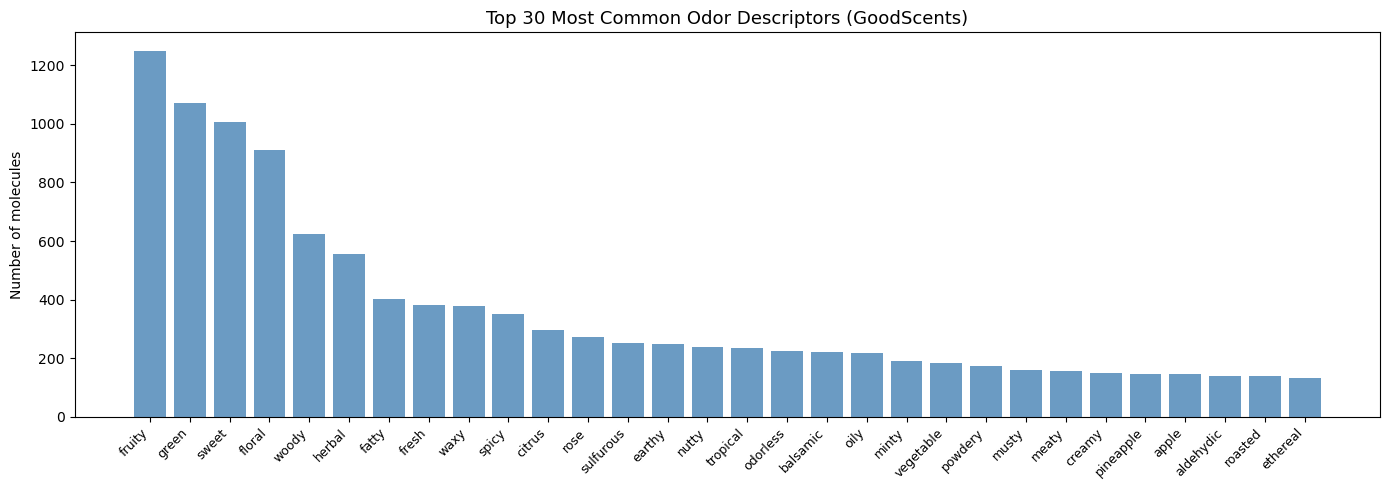

Total unique odor descriptors: 667
fruity    1250
green     1070
sweet     1007
floral     910
woody      623
herbal     556
fatty      402
fresh      382
waxy       379
spicy      352
dtype: int64


In [74]:
label_counts = label_df.sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
top_labels = label_counts.head(30)
ax.bar(range(len(top_labels)), top_labels.values, color='steelblue', alpha=0.8)
ax.set_xticks(range(len(top_labels)))
ax.set_xticklabels(top_labels.index, rotation=45, ha='right', fontsize=9)
ax.set_title('Top 30 Most Common Odor Descriptors (GoodScents)', fontsize=13)
ax.set_ylabel('Number of molecules')
plt.tight_layout()
plt.show()

print(f'Total unique odor descriptors: {len(label_counts)}')
print(label_counts.head(10))

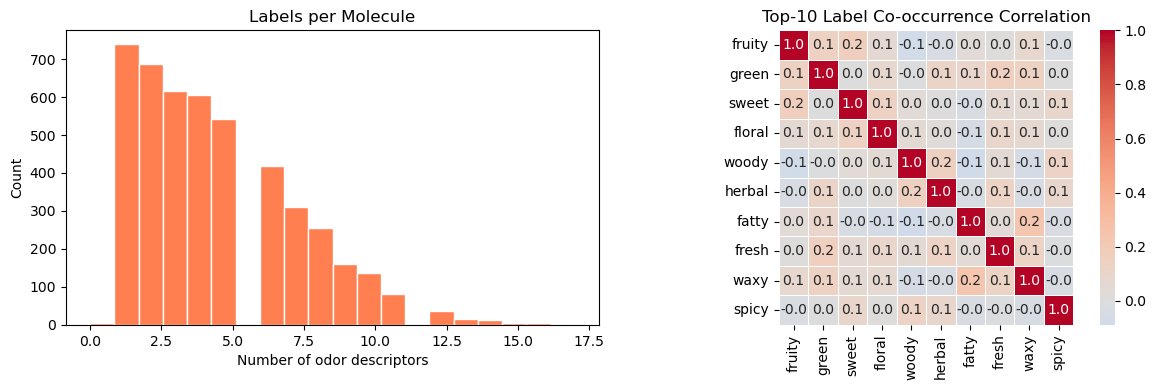

Avg labels per molecule: 4.4


In [76]:
labels_per_mol = label_df.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(labels_per_mol, bins=20, color='coral', edgecolor='white')
axes[0].set_title('Labels per Molecule')
axes[0].set_xlabel('Number of odor descriptors')
axes[0].set_ylabel('Count')

top10 = label_counts.head(10).index.tolist()
corr = label_df[top10].corr()
sns.heatmap(corr, ax=axes[1], cmap='coolwarm', center=0,
            annot=True, fmt='.1f', square=True, linewidths=0.5)
axes[1].set_title('Top-10 Label Co-occurrence Correlation')
plt.tight_layout()
plt.show()

print(f'Avg labels per molecule: {labels_per_mol.mean():.1f}')

In [78]:
print("Fetching CAS numbers for all CIDs via PubChem...")
cids = molecules.index.tolist()
cid_to_cas = {}

for i in range(0, len(cids), 100):
    batch = cids[i:i+100]
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{','.join(map(str,batch))}/synonyms/JSON"
    try:
        r = requests.get(url, timeout=30)
        if r.ok:
            for item in r.json().get('InformationList', {}).get('Information', []):
                cid = item['CID']
                for syn in item.get('Synonym', []):
                    if re.match(r'^\d{2,7}-\d{2}-\d$', syn):
                        cid_to_cas[cid] = syn
                        break
    except Exception as e:
        print(f"  Batch {i//100+1} failed: {e}")
    time.sleep(0.2)

print(f"\nFound CAS for {len(cid_to_cas)} / {len(cids)} CIDs")
print("Sample:", list(cid_to_cas.items())[:5])

Fetching CAS numbers for all CIDs via PubChem...

Found CAS for 4034 / 4565 CIDs
Sample: [(4, '78-96-6'), (49, '759-05-7'), (51, '328-50-7'), (58, '600-18-0'), (70, '816-66-0')]


In [80]:
behavior_cas = set(behavior.index.tolist())
cas_to_smiles = {}

for cid, cas in cid_to_cas.items():
    smiles = molecules.loc[cid, 'IsomericSMILES']
    if cas in behavior_cas and pd.notna(smiles):
        cas_to_smiles[cas] = smiles

print(f"Matched {len(cas_to_smiles)} molecules in both molecules.csv and behavior.csv")
print("Sample:", list(cas_to_smiles.items())[:3])

Matched 3755 molecules in both molecules.csv and behavior.csv
Sample: [('78-96-6', 'CC(CN)O'), ('759-05-7', 'CC(C)C(=O)C(=O)O'), ('328-50-7', 'C(CC(=O)O)C(=O)C(=O)O')]


In [82]:
def smiles_to_morgan(smiles, radius=2, n_bits=2048):
    """Convert a SMILES string to a Morgan fingerprint (ECFP4) numpy array."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    gen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
    return gen.GetFingerprintAsNumPy(mol)


fingerprints = {}
failed = 0

for cas, smiles in cas_to_smiles.items():
    fp = smiles_to_morgan(str(smiles))
    if fp is not None:
        fingerprints[cas] = fp
    else:
        failed += 1

fp_df = pd.DataFrame.from_dict(fingerprints, orient='index')
fp_df.index.name = 'CAS'
fp_df.columns = [f'bit_{i}' for i in range(fp_df.shape[1])]

print(f'Fingerprints generated: {len(fingerprints)} molecules ({failed} failed)')
print(f'Fingerprint matrix shape: {fp_df.shape}')

Fingerprints generated: 3755 molecules (0 failed)
Fingerprint matrix shape: (3755, 2048)


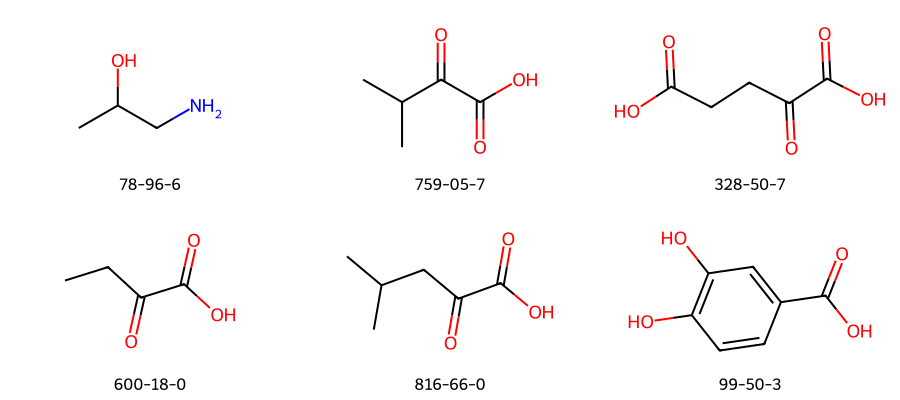

In [84]:
sample_items = list(cas_to_smiles.items())[:6]
sample_mols  = [Chem.MolFromSmiles(s) for _, s in sample_items if Chem.MolFromSmiles(s)]
legends      = [cas for cas, _ in sample_items[:len(sample_mols)]]

if sample_mols:
    img = Draw.MolsToGridImage(sample_mols, molsPerRow=3, subImgSize=(300, 200), legends=legends)
    display(img)

In [86]:
common_ids = fp_df.index.intersection(label_df.index)
print(f'Molecules with both fingerprints and labels: {len(common_ids)}')

X      = fp_df.loc[common_ids].values
Y_full = label_df.loc[common_ids]

MIN_SUPPORT = 20
selected_labels = Y_full.sum(axis=0)[Y_full.sum(axis=0) >= MIN_SUPPORT].index.tolist()
Y = Y_full[selected_labels].values

print(f'Labels after min-support filter: {len(selected_labels)}')
print(f'X: {X.shape}  |  Y: {Y.shape}')

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}')

Molecules with both fingerprints and labels: 3755
Labels after min-support filter: 154
X: (3755, 2048)  |  Y: (3755, 154)
Train: 3004  |  Test: 751


In [88]:
base_clf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.3,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

model = MultiOutputClassifier(base_clf, n_jobs=-1)

print('Training... (1-3 minutes)')
model.fit(X_train, Y_train)
print('Done!')

Training... (1-3 minutes)
Done!


In [90]:
Y_pred       = model.predict(X_test)
Y_pred_proba = np.column_stack([clf.predict_proba(X_test)[:, 1] for clf in model.estimators_])

f1_micro = f1_score(Y_test, Y_pred, average='micro', zero_division=0)
f1_macro = f1_score(Y_test, Y_pred, average='macro', zero_division=0)

auc_scores = [
    roc_auc_score(Y_test[:, i], Y_pred_proba[:, i])
    for i in range(Y_test.shape[1])
    if len(np.unique(Y_test[:, i])) > 1
]

print(f'F1 micro : {f1_micro:.3f}')
print(f'F1 macro : {f1_macro:.3f}')
print(f'Mean AUC : {np.mean(auc_scores):.3f}  (across {len(auc_scores)} labels)')

F1 micro : 0.290
F1 macro : 0.151
Mean AUC : 0.826  (across 154 labels)


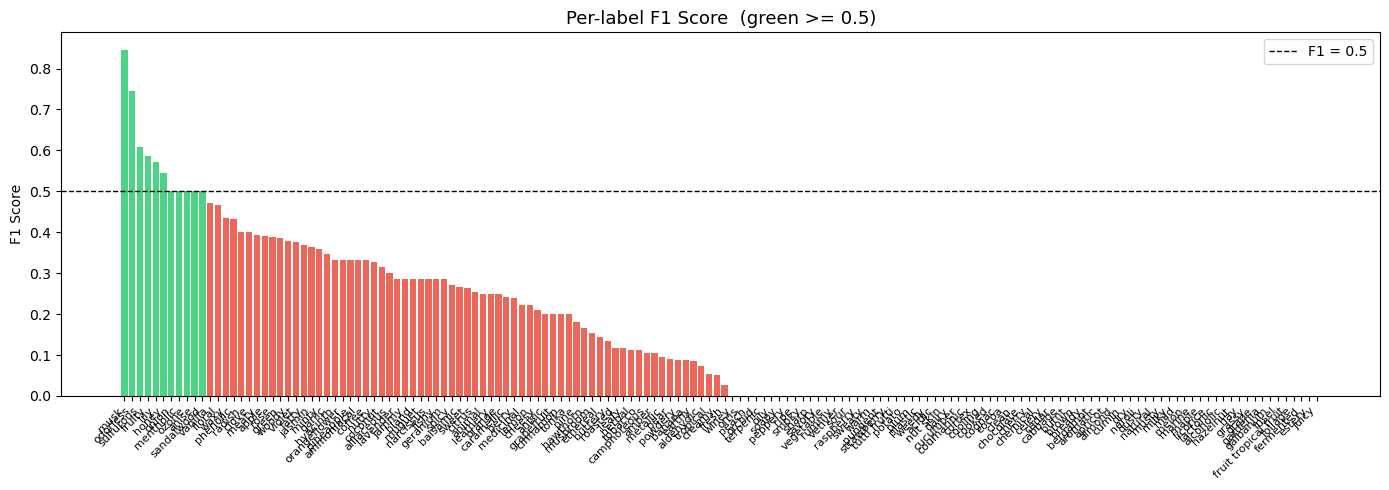

In [92]:
per_label_f1 = f1_score(Y_test, Y_pred, average=None, zero_division=0)
f1_series = pd.Series(per_label_f1, index=selected_labels).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#2ecc71' if v >= 0.5 else '#e74c3c' for v in f1_series.values]
ax.bar(range(len(f1_series)), f1_series.values, color=colors, alpha=0.85)
ax.set_xticks(range(len(f1_series)))
ax.set_xticklabels(f1_series.index, rotation=45, ha='right', fontsize=8)
ax.axhline(0.5, color='black', linestyle='--', linewidth=1, label='F1 = 0.5')
ax.set_title('Per-label F1 Score  (green >= 0.5)', fontsize=13)
ax.set_ylabel('F1 Score')
ax.legend()
plt.tight_layout()
plt.show()

In [94]:
best_label     = f1_series.idxmax()
best_label_idx = selected_labels.index(best_label)
print(f'Explaining: "{best_label}"  (F1 = {f1_series.max():.3f})')

n_shap        = min(100, X_test.shape[0])
X_shap_sample = X_test[:n_shap]

explainer   = shap.TreeExplainer(model.estimators_[best_label_idx])
shap_values = explainer.shap_values(X_shap_sample)

sv = shap_values[1] if isinstance(shap_values, list) else shap_values
print(f'SHAP values shape: {sv.shape}')

Explaining: "musk"  (F1 = 0.846)
SHAP values shape: (100, 2048)


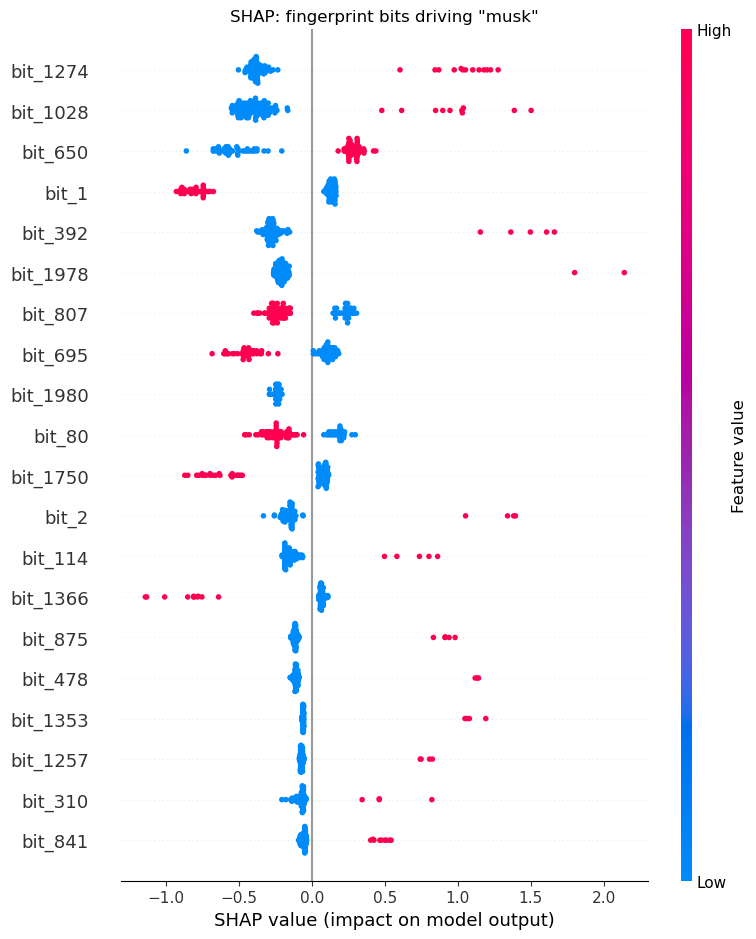

In [100]:
feature_names = [f'bit_{i}' for i in range(X_shap_sample.shape[1])]

plt.title(f'SHAP: fingerprint bits driving "{best_label}"')
shap.summary_plot(
    sv, X_shap_sample,
    feature_names=feature_names,
    max_display=20,
    show=True
)

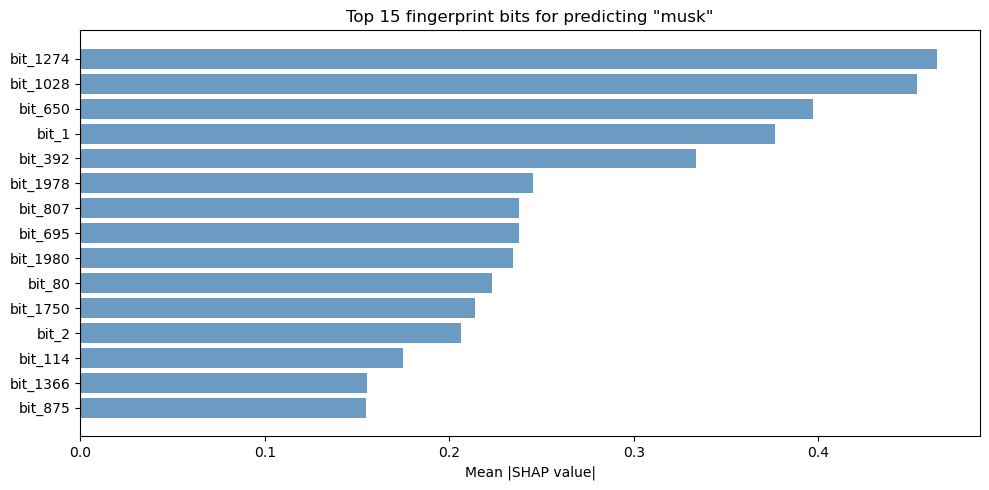

In [102]:
mean_abs_shap = np.abs(sv).mean(axis=0)
top_idx = np.argsort(mean_abs_shap)[::-1][:15]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(15), mean_abs_shap[top_idx][::-1], color='steelblue', alpha=0.8)
ax.set_yticks(range(15))
ax.set_yticklabels([f'bit_{i}' for i in top_idx[::-1]])
ax.set_xlabel('Mean |SHAP value|')
ax.set_title(f'Top 15 fingerprint bits for predicting "{best_label}"', fontsize=12)
plt.tight_layout()
plt.show()

In [106]:
def predict_odor_profile(smiles, top_n=10):
    """Given a SMILES string, return predicted odor descriptors with confidence."""
    fp = smiles_to_morgan(smiles)
    if fp is None:
        print(f'Invalid SMILES: {smiles}')
        return None
    proba = np.array([clf.predict_proba(fp.reshape(1, -1))[0, 1] for clf in model.estimators_])
    return pd.Series(proba, index=selected_labels).sort_values(ascending=False).head(top_n)


def plot_odor_profile(smiles, name='Molecule'):
    profile = predict_odor_profile(smiles)
    if profile is None: return

    mol = Chem.MolFromSmiles(smiles)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].imshow(Draw.MolToImage(mol, size=(300, 200)))
    axes[0].axis('off')
    axes[0].set_title(name, fontsize=10)

    axes[1].barh(range(len(profile)), profile.values[::-1], color='mediumpurple', alpha=0.85)
    axes[1].set_yticks(range(len(profile)))
    axes[1].set_yticklabels(profile.index[::-1])
    axes[1].axvline(0.5, color='red', linestyle='--', lw=1, label='threshold')
    axes[1].set_xlabel('Predicted probability')
    axes[1].set_title('Predicted Odor Profile')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    for label, score in profile.items():
        bar = '█' * int(score * 20)
        print(f'  {label:<15} {bar} {score:.2f}')

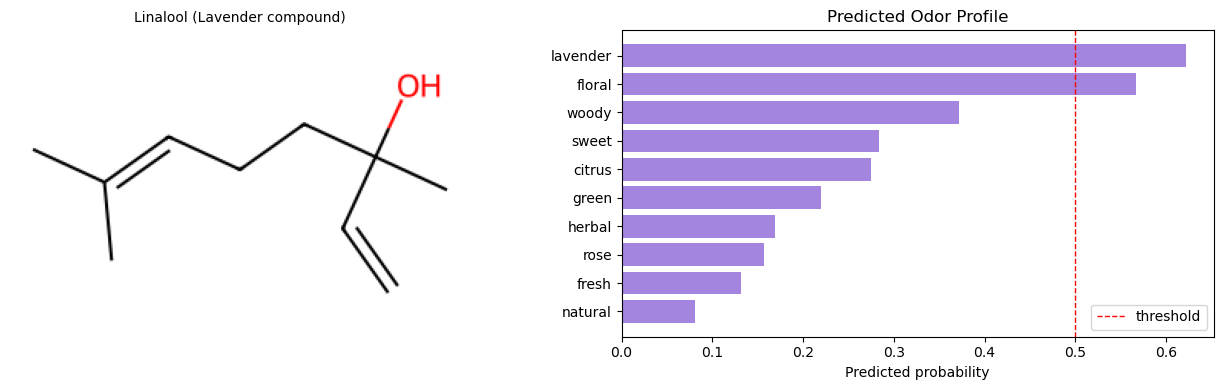

  lavender        ████████████ 0.62
  floral          ███████████ 0.57
  woody           ███████ 0.37
  sweet           █████ 0.28
  citrus          █████ 0.27
  green           ████ 0.22
  herbal          ███ 0.17
  rose            ███ 0.16
  fresh           ██ 0.13
  natural         █ 0.08


In [108]:
plot_odor_profile('OC(CCC=C(C)C)(C=C)C', 'Linalool (Lavender compound)')

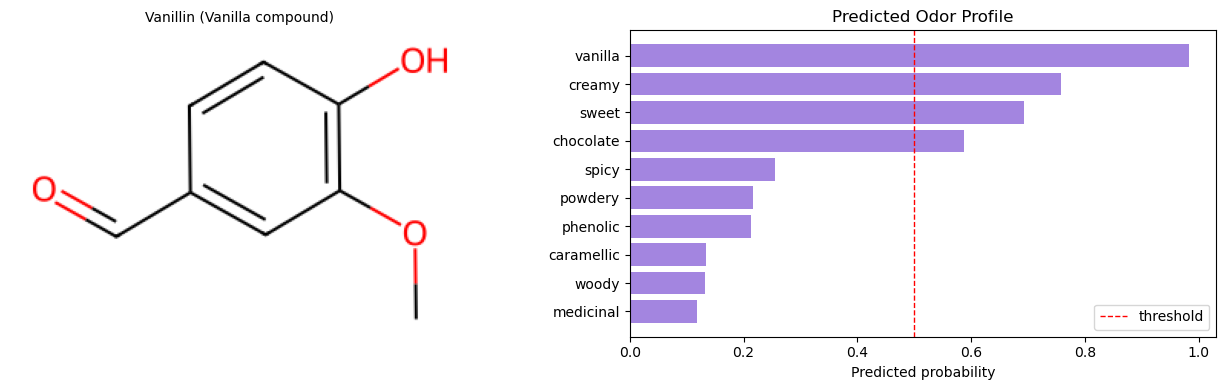

  vanilla         ███████████████████ 0.98
  creamy          ███████████████ 0.76
  sweet           █████████████ 0.69
  chocolate       ███████████ 0.59
  spicy           █████ 0.26
  powdery         ████ 0.22
  phenolic        ████ 0.21
  caramellic      ██ 0.13
  woody           ██ 0.13
  medicinal       ██ 0.12


In [110]:
plot_odor_profile('COc1cc(C=O)ccc1O', 'Vanillin (Vanilla compound)')

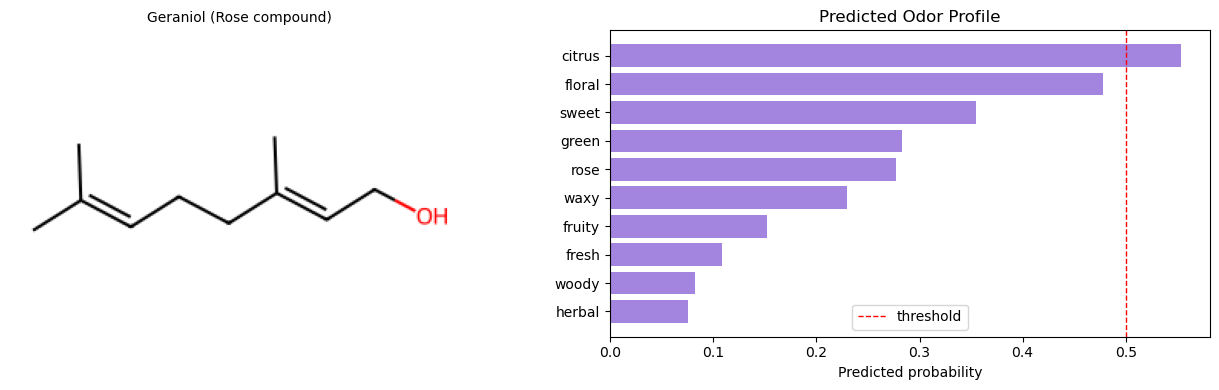

  citrus          ███████████ 0.55
  floral          █████████ 0.48
  sweet           ███████ 0.35
  green           █████ 0.28
  rose            █████ 0.28
  waxy            ████ 0.23
  fruity          ███ 0.15
  fresh           ██ 0.11
  woody           █ 0.08
  herbal          █ 0.08


In [112]:
MY_SMILES = 'CC(C)=CCC/C(C)=C/CO'  # Geraniol — rose-like
plot_odor_profile(MY_SMILES, 'Geraniol (Rose compound)')

In [114]:
print('Building ingredient database profiles...')

all_probas = np.column_stack([clf.predict_proba(X)[:, 1] for clf in model.estimators_])

db_profiles = pd.DataFrame(all_probas, index=common_ids, columns=selected_labels)
db_profiles['smiles'] = [cas_to_smiles.get(cas, None) for cas in common_ids]

print(f'Database ready: {db_profiles.shape[0]} molecules')

Building ingredient database profiles...
Database ready: 3755 molecules


In [116]:
def recommend_ingredients(target_descriptors: dict, top_n: int = 10):
    """
    Given target odor descriptors and desired intensities (0-1),
    return the top N molecules that best match via cosine similarity.

    Example:
        recommend_ingredients({'floral': 0.9, 'woody': 0.7, 'musky': 0.5})
    """
    query = np.zeros(len(selected_labels))
    valid = {}
    for desc, strength in target_descriptors.items():
        d = desc.lower().strip()
        if d in selected_labels:
            query[selected_labels.index(d)] = float(strength)
            valid[d] = strength
        else:
            print(f'  Warning: "{desc}" not in model. Skipped.')

    if not valid:
        print('No valid descriptors. Available labels:')
        print(selected_labels)
        return None

    print(f'Querying for: {valid}')

    scores   = cosine_similarity(query.reshape(1, -1), db_profiles[selected_labels].values)[0]
    top_idx  = np.argsort(scores)[::-1][:top_n]
    top_ids  = common_ids[top_idx]

    result = db_profiles.loc[top_ids, list(valid.keys()) + ['smiles']].copy()
    result['similarity_score'] = scores[top_idx]
    return result.sort_values('similarity_score', ascending=False)


print('Recommender ready!')
print(f'Available descriptors: {selected_labels}')

Recommender ready!
Available descriptors: ['acidic', 'alcoholic', 'aldehydic', 'alliaceous', 'almond', 'amber', 'ammoniacal', 'animal', 'anise', 'anisic', 'apple', 'apricot', 'aromatic', 'balsamic', 'banana', 'bergamot', 'berry', 'bland', 'bready', 'brown', 'burnt', 'buttery', 'cabbage', 'camphoreous', 'caramellic', 'cedar', 'celery', 'cheesy', 'chemical', 'cherry', 'chocolate', 'cinnamon', 'citrus', 'clean', 'clove', 'cocoa', 'coconut', 'coffee', 'cognac', 'cooked', 'cooling', 'cortex', 'coumarinic', 'creamy', 'cucumber', 'cumin', 'dairy', 'dry', 'dusty', 'earthy', 'estery', 'ethereal', 'fatty', 'fermented', 'fishy', 'floral', 'foliage', 'fresh', 'fruit tropical fruit', 'fruity', 'fusel', 'galbanum', 'gardenia', 'garlic', 'geranium', 'grape', 'grapefruit', 'grassy', 'green', 'hawthorn', 'hay', 'hazelnut', 'herbal', 'honey', 'hyacinth', 'jammy', 'jasmin', 'juicy', 'lactonic', 'lavender', 'leafy', 'leathery', 'lemon', 'licorice', 'lily', 'maple', 'marine', 'meaty', 'medicinal', 'melon',

In [128]:
results = recommend_ingredients({
    'woody': 0.9,
    'musk': 0.8,
    'sweet': 0.4,
}, top_n=10)

display(results.round(3))

Querying for: {'woody': 0.9, 'musk': 0.8, 'sweet': 0.4}


,woody,musk,sweet,smiles,similarity_score
CAS,,,,,
33704-61-9,0.629,0.440,0.257,CC1C(C2=C(C1(C)C)C(=O)CCC2)(C)C,0.866
13171-00-1,0.636,0.996,0.371,CC(=O)C1=C2CCC(C2=CC(=C1)C(C)(C)C)(C)C,0.830
1222-05-5,0.239,0.756,0.477,CC1COCC2=CC3=C(C=C12)C(C(C3(C)C)C)(C)C,0.811
89780-06-3,0.708,0.760,0.591,CC1=CC2=C(C(=C1C=O)OC)C(CCC2(C)C)(C)C,0.806
90-42-6,0.662,0.474,0.293,C1CCC(CC1)C2CCCCC2=O,0.804
4755-83-3,0.239,0.955,0.523,CC1C(C2=C(C1(C)C)C=C(C=C2)C(=O)C)(C)C,0.788
92-68-2,0.651,0.240,0.156,C1CCC(CC1)C2CCC(=O)CC2,0.783
88-29-9,0.179,0.963,0.536,CCC1=CC2=C(C=C1C(=O)C)C(CCC2(C)C)(C)C,0.757
116-66-5,0.382,0.693,0.547,CC1=C(C=C2C(=C1[N+](=O)[O-])C(CC2(C)C)(C)C)[N+...,0.756


In [120]:
results2 = recommend_ingredients({
    'citrus': 0.9,
    'floral': 0.7,
    'fresh':  0.8,
    'green':  0.5,
}, top_n=10)

display(results2.round(3))

Querying for: {'citrus': 0.9, 'floral': 0.7, 'fresh': 0.8, 'green': 0.5}


,citrus,floral,fresh,green,smiles,similarity_score
CAS,,,,,,
72403-67-9,0.766,0.544,0.565,0.243,CC(=CCCC1=CCC[C@@H](C1)COC(=O)C)C,0.834
106-72-9,0.596,0.359,0.540,0.551,CC(CCC=C(C)C)C=O,0.827
744251-93-2,0.385,0.609,0.354,0.231,CC(=CCC/C(=C/CNC(=O)C1CC1)/C)C,0.820
67845-42-5,0.763,0.519,0.723,0.242,CC(CCC=C(C)C)CC=NC1=CC=CC=C1C(=O)OC,0.820
22457-25-6,0.665,0.562,0.160,0.249,CC(CCC=C(C)C)CC=NO,0.816
2550-11-0,0.514,0.226,0.415,0.427,CCC(=O)C(C)CC=C(C)C,0.808
78-69-3,0.570,0.278,0.573,0.102,CCC(C)(CCCC(C)C)O,0.802
35931-93-2,0.907,0.747,0.096,0.195,C[C@H](CCC=C(C)C)CC#N,0.782
18479-51-1,0.431,0.596,0.233,0.215,CCC(C)(CCC=C(C)C)O,0.782


Top recommended molecules for woody-musky accord:


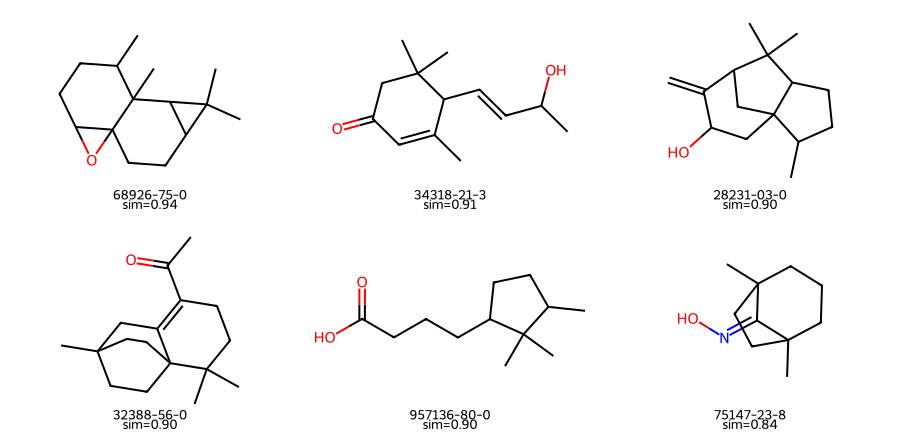

In [122]:
def visualise_recommendations(results_df, n=6):
    smiles_list = results_df['smiles'].dropna().head(n).tolist()
    mols    = [Chem.MolFromSmiles(s) for s in smiles_list if Chem.MolFromSmiles(s)]
    scores  = results_df['similarity_score'].head(n).tolist()
    cas_ids = results_df.index[:n].tolist()
    legends = [f'{cas_ids[i]}\nsim={scores[i]:.2f}' for i in range(len(mols))]
    img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(300, 220), legends=legends)
    display(img)

if results is not None:
    print('Top recommended molecules for woody-musky accord:')
    visualise_recommendations(results)

In [124]:
artifact = {
    'model': model,
    'selected_labels': selected_labels,
    'db_profiles': db_profiles,
    'common_ids': common_ids,
    'cas_to_smiles': cas_to_smiles,
    'metrics': {
        'f1_micro': f1_micro,
        'f1_macro': f1_macro,
        'mean_auc': float(np.mean(auc_scores))
    }
}

with open('scentml_model.pkl', 'wb') as f:
    pickle.dump(artifact, f)

print('Saved to scentml_model.pkl')
print(f'F1 micro: {f1_micro:.3f}  |  F1 macro: {f1_macro:.3f}  |  Mean AUC: {np.mean(auc_scores):.3f}')

Saved to scentml_model.pkl
F1 micro: 0.290  |  F1 macro: 0.151  |  Mean AUC: 0.826


In [126]:
# Instead of default 0.5 threshold, use 0.3
Y_pred_tuned = (Y_pred_proba >= 0.3).astype(int)

f1_micro_tuned = f1_score(Y_test, Y_pred_tuned, average='micro', zero_division=0)
f1_macro_tuned = f1_score(Y_test, Y_pred_tuned, average='macro', zero_division=0)

print(f'Tuned F1 micro: {f1_micro_tuned:.3f}')
print(f'Tuned F1 macro: {f1_macro_tuned:.3f}')

Tuned F1 micro: 0.378
Tuned F1 macro: 0.216
